# Geodemographic Clustering Case Study

Demonstrates that learned embeddings (100D, 500 Epochs) can be used for geodemographic classification.
Creates 8-cluster classifications from AE and PCA embeddings, evaluates cluster quality.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import pickle

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings('ignore')

## Configuration

In [2]:
# Parameters
target_dim = 100
n_clusters = 8  # Match OAC supergroups
n_inits = 10000  # Must match 7a
random_seed = 20210321

# Paths
geofiles_dir = "../data/geofiles"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
oac_path = "../data/OAC/OAC_assignment.csv"

# Stability checkpoint path (for median run embeddings)
stability_path = f"../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_{target_dim}d.pkl"

# Input - clustering results from previous run
input_dir = "./clustering_results/"

# Output - publication plots
output_dir = "./plots/pub_plots/"
os.makedirs(output_dir, exist_ok=True)

print(f"Creating {n_clusters} clusters from {target_dim}D embeddings (500 EPOCH MEDIAN RUN)")
print(f"Random seed: {random_seed}")
print(f"n_inits: {n_inits}")

Creating 8 clusters from 100D embeddings (500 EPOCH MEDIAN RUN)
Random seed: 20210321
n_inits: 10000


## Load Data

In [3]:
# Load original census data
print("Loading census data...")
df_census = pd.read_parquet(cleaned_data_path)
df_census = df_census.set_index('OA')
print(f"Census data: {df_census.shape}")

# Load PCA embeddings (compute on the fly - deterministic)
print(f"\nComputing PCA {target_dim}D embeddings...")
pca = PCA(n_components=target_dim, random_state=random_seed)
pca_embeddings = pca.fit_transform(df_census)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Load AE embeddings from stability checkpoint (500 EPOCH MEDIAN RUN)
print(f"\nLoading stability checkpoint from: {stability_path}")
with open(stability_path, 'rb') as f:
    checkpoint = pickle.load(f)

embeddings_list = checkpoint['embeddings_list']
reco_errors_list = checkpoint['reco_errors_list']
n_runs = checkpoint['n_runs']
print(f"Loaded {n_runs} runs from stability checkpoint")

# Find the median run (by overall RMSE)
rmse_per_run = []
for run_idx, reco_err in enumerate(reco_errors_list):
    rmse = np.sqrt(reco_err.mean()) * 100
    rmse_per_run.append(rmse)

rmse_per_run = np.array(rmse_per_run)
median_rmse = np.median(rmse_per_run)
median_run_idx = np.argmin(np.abs(rmse_per_run - median_rmse))

print(f"\nMedian RMSE: {median_rmse:.4f}%")
print(f"Median run index: {median_run_idx} (RMSE = {rmse_per_run[median_run_idx]:.4f}%)")

# Get median run embeddings
ae_embeddings = embeddings_list[median_run_idx]
ae_latent_df = pd.DataFrame(ae_embeddings, index=df_census.index)
print(f"\nAE embeddings (median run): {ae_latent_df.shape}")

# Load OAC
print(f"\nLoading OAC classifications...")
oac = pd.read_csv(oac_path)
oac = oac[['Geography_Code', 'Supergroup8']].rename(columns={'Geography_Code': 'OA'})
oac = oac.set_index('OA')
oac = oac.reindex(df_census.index)
print(f"OAC: {oac.shape}")
print(f"OAC Supergroups: {oac['Supergroup8'].nunique()} unique groups")

Loading census data...
Census data: (188880, 408)

Computing PCA 100D embeddings...
Explained variance: 0.984

Loading stability checkpoint from: ../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_100d.pkl
Loaded 10 runs from stability checkpoint

Median RMSE: 0.7931%
Median run index: 5 (RMSE = 0.7925%)

AE embeddings (median run): (188880, 100)

Loading OAC classifications...
OAC: (188880, 1)
OAC Supergroups: 8 unique groups


In [4]:
# Load the kmeans clustering results for AE and PCA embeddings
clustering_file = f"{input_dir}/cluster_assignments_{target_dim}d_k{n_clusters}_n{n_inits}.csv"
pca_model_file = f"{input_dir}/kmeans_pca_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"
ae_model_file = f"{input_dir}/kmeans_ae_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"

print(f"Loading clustering results from {clustering_file}...")
clusters_df = pd.read_csv(clustering_file, index_col=0)

print(f"Loaded {len(clusters_df)} cluster assignments")
print(f"KMeans models loaded from {pca_model_file} and {ae_model_file}")

Loading clustering results from ./clustering_results//cluster_assignments_100d_k8_n10000.csv...
Loaded 188880 cluster assignments
KMeans models loaded from ./clustering_results//kmeans_pca_100d_k8_n10000.joblib and ./clustering_results//kmeans_ae_100d_k8_n10000.joblib


In [5]:
mapping_ae = {
    0: 5,
    1: 7,
    2: 8,
    3: 6,
    4: 1,
    5: 4,
    6: 3,
    7: 2
}

clusters_df["ae_cluster"] = clusters_df["ae_cluster"].map(mapping_ae)

In [6]:
# Step 1: Load geometries
print("Loading geometries for mapping...")
gdf = gpd.read_file(f"{geofiles_dir}/Output_Areas_2021_EW_BGC_V2_-5587136561181621407.gpkg")
gdf = gdf[['OA21CD', 'geometry']].rename(columns={'OA21CD': 'OA'})
gdf = gdf.set_index('OA')
# Merge with clusters
gdf = gdf.join(clusters_df)
print(f"GeoDataFrame: {gdf.shape}")

# Load London boundary for plotting
print("Loading London boundary...")
lads_gdf = gpd.read_file(f"{geofiles_dir}/Local_Authority_Districts_December_2022_UK_BGC_V2_5759908710055972638.gpkg")
london_boundary = lads_gdf[lads_gdf['LAD22CD'].str.startswith('E09')].dissolve()
if london_boundary.crs != gdf.crs:
    london_boundary = london_boundary.to_crs(gdf.crs)

# Load England/Wales boundary for plotting
print("Loading country boundaries...")
countries_gdf = gpd.read_file(f"{geofiles_dir}/Countries_December_2022_UK_BGC_1943732719298389253.gpkg")
eng_wales_gdf = countries_gdf[countries_gdf['CTRY22CD'].str.startswith(('E', 'W'))]
if eng_wales_gdf.crs != gdf.crs:
    eng_wales_gdf = eng_wales_gdf.to_crs(gdf.crs)

print("✓ All geometries loaded")

Loading geometries for mapping...
GeoDataFrame: (188880, 4)
Loading London boundary...
Loading country boundaries...
✓ All geometries loaded


In [7]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Cluster colour palette used for the published Figure 6 (Set1 permutation 03)
palettes_to_plot = {
    'Set1_perm03': {
        1: '#ff7f00',  # orange
        2: '#984ea3',  # purple
        3: '#a65628',  # brown
        4: '#ffff33',  # yellow
        5: '#377eb8',  # blue
        6: '#4daf4a',  # green
        7: '#f781bf',  # pink
        8: '#e41a1c',  # red
    },
}



Rendering Set1_perm03...


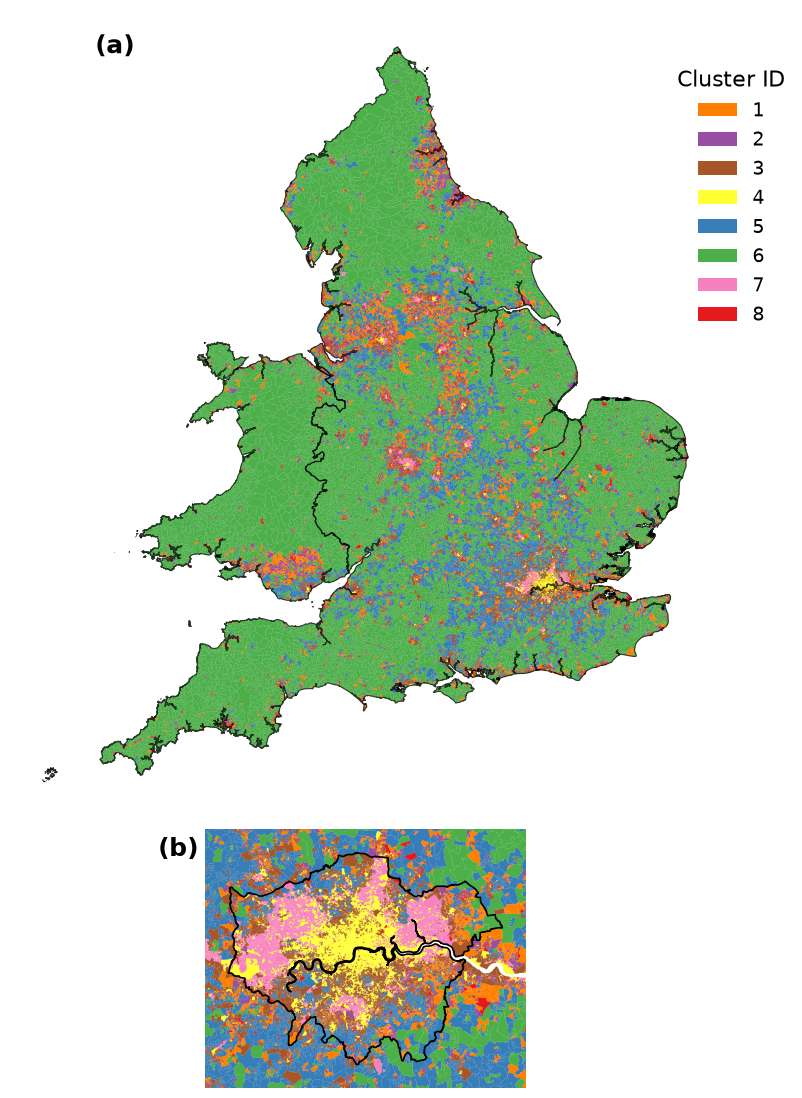

Saved: ./plots/pub_plots//publication_map_ae_100d_Set1_perm03.png


In [8]:

# London bounds
minx, miny, maxx, maxy = london_boundary.total_bounds
buffer = 5000
london_bounds = {
    'minx': minx - buffer, 'maxx': maxx + buffer,
    'miny': miny - buffer, 'maxy': maxy + buffer
}
gdf_london = gdf.cx[london_bounds['minx']:london_bounds['maxx'],
                     london_bounds['miny']:london_bounds['maxy']]

for pal_name, cluster_colors in palettes_to_plot.items():
    print(f"\nRendering {pal_name}...")
    color_list = [cluster_colors[i] for i in range(1, n_clusters + 1)]
    cmap = ListedColormap(color_list)
    bounds = np.arange(0.5, n_clusters + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    fig, axes = plt.subplots(2, 1, figsize=(10, 14),
                             gridspec_kw={'height_ratios': [2.5, 0.8],
                                          'hspace': 0.02})
    ax_uk, ax_ldn = axes

    # UK map
    gdf.plot(column='ae_cluster', ax=ax_uk, cmap=cmap, norm=norm,
             linewidth=0.1, edgecolor='face', legend=False)
    eng_wales_gdf.boundary.plot(ax=ax_uk, linewidth=0.8, edgecolor='black', alpha=0.7)
    ax_uk.text(0.12, 0.97, '(a)', transform=ax_uk.transAxes,
               fontsize=18, fontweight='bold', va='top', ha='left')
    ax_uk.axis('off')

    # London map — unclipped, with boundary overlay
    gdf_london.plot(column='ae_cluster', ax=ax_ldn, cmap=cmap, norm=norm,
                    linewidth=0.1, edgecolor='face', legend=False)
    london_boundary.boundary.plot(ax=ax_ldn, linewidth=1.2, edgecolor='black')
    ax_ldn.set_xlim(london_bounds['minx'], london_bounds['maxx'])
    ax_ldn.set_ylim(london_bounds['miny'], london_bounds['maxy'])
    ax_ldn.set_aspect('equal')
    ax_ldn.text(-0.02, 0.97, '(b)', transform=ax_ldn.transAxes,
                fontsize=18, fontweight='bold', va='top', ha='right')
    ax_ldn.axis('off')

    for ax in [ax_uk, ax_ldn]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')

    legend_elements = [Patch(facecolor=cluster_colors[i], label=str(i))
                       for i in range(1, n_clusters + 1)]
    fig.legend(handles=legend_elements, loc='upper right', ncol=1,
               fontsize=14, frameon=False, title='Cluster ID', title_fontsize=16,
               bbox_to_anchor=(0.95, 0.85))

    plt.tight_layout()
    save_path = f"{output_dir}/publication_map_ae_{target_dim}d_{pal_name}.png"
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    #transparent for presentation, but white for publication
    plt.savefig(save_path.replace('.png', '_transparent.png'), dpi=600, bbox_inches='tight', facecolor='none', edgecolor='none')
    plt.show()
    print(f"Saved: {save_path}")


Creating publication-quality AE cluster vs OAC overlap visualisation...



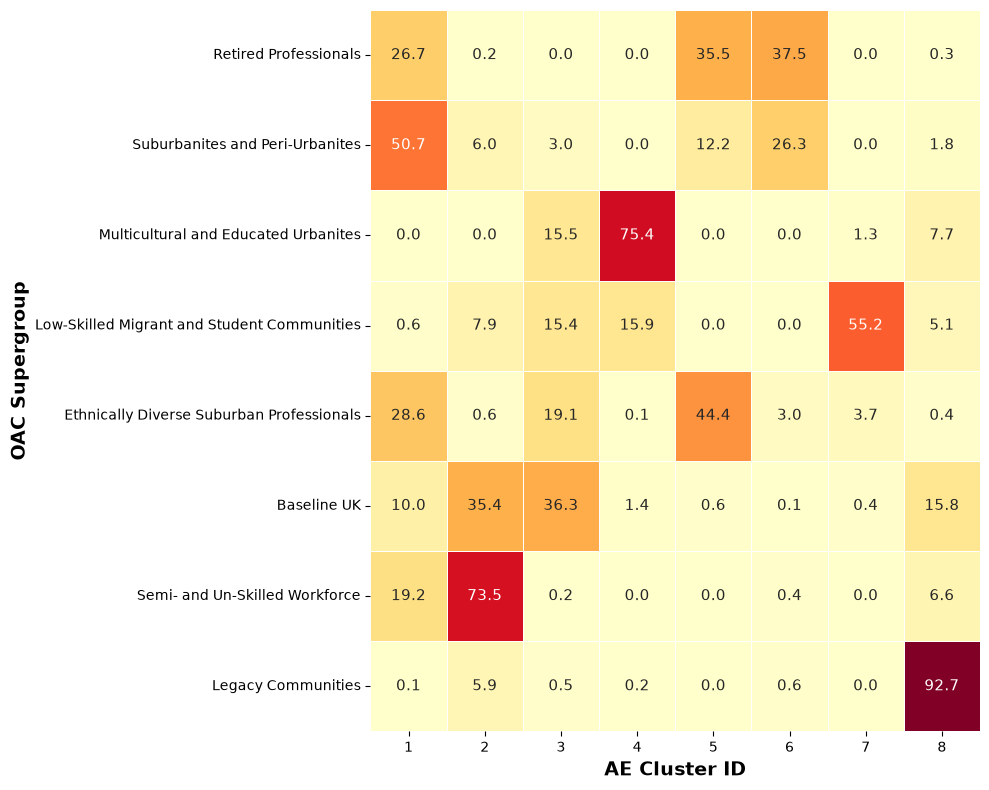

Saved heatmap to ./plots/pub_plots//ae_oac_overlap_publication_100d.png
Saved transparent: ./plots/pub_plots//ae_oac_overlap_publication_100d_transparent.png and .pdf


In [9]:
# Publication-quality AE cluster vs OAC overlap analysis
print("Creating publication-quality AE cluster vs OAC overlap visualisation...\n")

# OAC Supergroup names
oac_names = {
    1: "Retired Professionals",
    2: "Suburbanites and Peri-Urbanites",
    3: "Multicultural and Educated Urbanites",
    4: "Low-Skilled Migrant and Student Communities",
    5: "Ethnically Diverse Suburban Professionals",
    6: "Baseline UK",
    7: "Semi- and Un-Skilled Workforce",
    8: "Legacy Communities"
}

# Recompute overlap for AE only with nice labels
def cluster_oac_overlap_named(cluster_labels, oac_labels, oac_names):
    """Return count and percentage matrices with named OAC labels."""
    valid_mask = ~pd.isna(oac_labels)
    oac_valid = oac_labels[valid_mask]
    clusters_valid = cluster_labels[valid_mask] # Fix: add 1 to convert 0-indexed to 1-indexed
    
    oac_ids = list(range(1, n_clusters + 1))
    cluster_ids = list(range(1, n_clusters + 1))
    
    counts = pd.crosstab(oac_valid, clusters_valid)
    counts = counts.reindex(index=oac_ids, columns=cluster_ids, fill_value=0)
    
    # Rename index to OAC names
    counts.index = [oac_names[i] for i in counts.index]
    counts.columns = [str(i) for i in counts.columns]
    
    # Row-wise percentages: for each OAC, what % falls into each AE cluster
    percentages = counts.divide(counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
    percentages = percentages.fillna(0)
    
    return counts, percentages

ae_counts_named, ae_percent_named = cluster_oac_overlap_named(
    clusters_df['ae_cluster'].values, oac['Supergroup8'].values, oac_names
)

# === Publication Heatmap (OAC as rows, AE Cluster as columns) ===
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(ae_percent_named, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, cbar=False,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11})

ax.set_xlabel('AE Cluster ID', fontsize=14, fontweight='bold')
ax.set_ylabel('OAC Supergroup', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)

plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f"{output_dir}/ae_oac_overlap_publication_{target_dim}d.png", 
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(f"{output_dir}/ae_oac_overlap_publication_{target_dim}d.jpeg", 
            dpi=600, bbox_inches='tight', facecolor='white')
# Transparent versions
plt.savefig(f"{output_dir}/ae_oac_overlap_publication_{target_dim}d_transparent.png", 
            dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(f"{output_dir}/ae_oac_overlap_publication_{target_dim}d_transparent.pdf", 
            bbox_inches='tight', transparent=True)
plt.show()

print(f"Saved heatmap to {output_dir}/ae_oac_overlap_publication_{target_dim}d.png")
print(f"Saved transparent: {output_dir}/ae_oac_overlap_publication_{target_dim}d_transparent.png and .pdf")

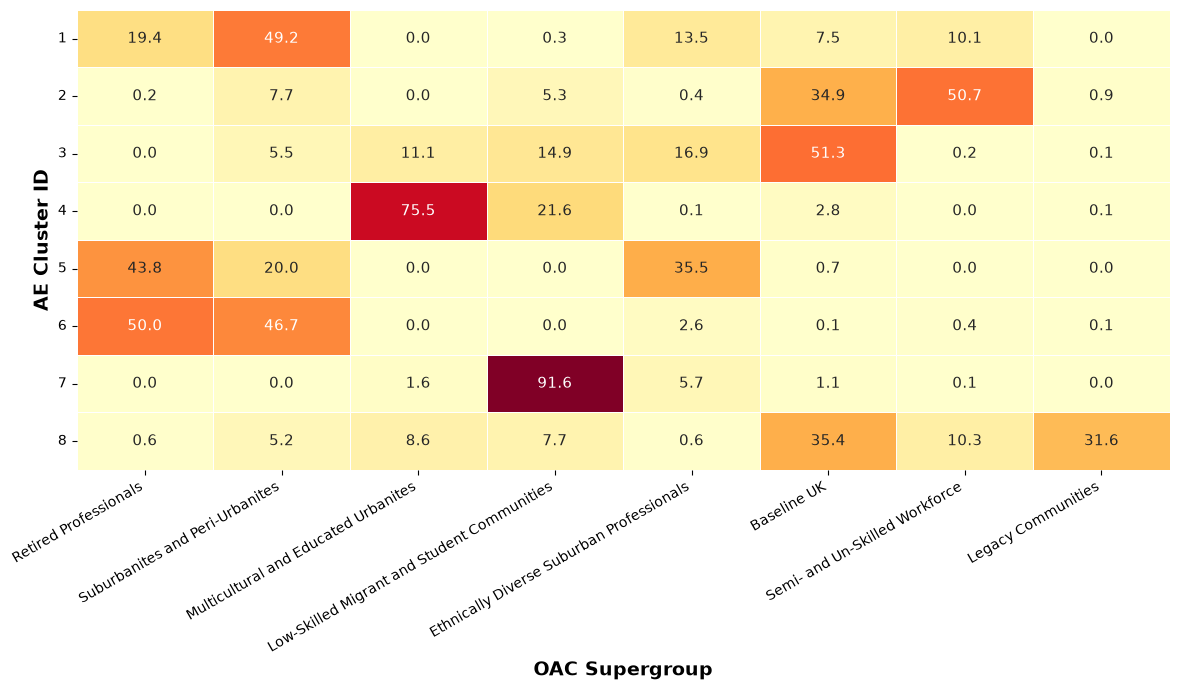

Saved transpose to ./plots/pub_plots//ae_oac_overlap_transpose_100d.png


In [10]:
# === Transposed version: AE Cluster as rows, OAC as columns ===
# Column-normalised on the original: each AE cluster sums to 100%
# Answers: "given an OA is in this AE cluster, what % came from each OAC?"
ae_percent_colnorm = ae_counts_named.divide(
    ae_counts_named.sum(axis=0).replace(0, np.nan), axis=1
) * 100
ae_percent_colnorm = ae_percent_colnorm.fillna(0).T  # transpose so AE clusters are rows

fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(ae_percent_colnorm, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, cbar=False,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11})

ax.set_xlabel('OAC Supergroup', fontsize=14, fontweight='bold')
ax.set_ylabel('AE Cluster ID', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f"{output_dir}/ae_oac_overlap_transpose_{target_dim}d.png",
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(f"{output_dir}/ae_oac_overlap_transpose_{target_dim}d.jpeg",
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(f"{output_dir}/ae_oac_overlap_transpose_{target_dim}d_transparent.png",
            dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(f"{output_dir}/ae_oac_overlap_transpose_{target_dim}d_transparent.pdf",
            bbox_inches='tight', transparent=True)
plt.show()

print(f"Saved transpose to {output_dir}/ae_oac_overlap_transpose_{target_dim}d.png")

## AE vs PCA: same clustering, or different maps?

Reviewer request: alongside the AE clustering map (Figure 6), produce a **comparable PCA
clustering map** and **identify the areas classified differently** by the two
dimensionality-reduction methods, with a view to the **policy implications** — where the
choice of AE vs PCA changes an area's classification, resources/interventions keyed to that
classification would be targeted differently.

Direction: PCA is the conventional baseline, so we frame the comparison **PCA → AE** — starting
from the standard PCA classification, where does the AE relocate areas.

This section:
1. **Aligns** PCA cluster labels to the AE label frame (Hungarian matching) so the two are directly comparable, and reports the % of OAs classified identically + the Adjusted Rand Index.
2. **Transition matrix** (PCA → AE) heatmap — the reclassification table.
3. **Sankey** of PCA → AE flows built from that table.
4. **PCA publication map** matching the AE Figure 6 style.
5. **Disagreement map** showing where the two methods place an OA in different clusters, plus the largest PCA → AE reclassification flows for the policy discussion.

In [11]:
# Align PCA cluster labels to the AE label frame.
# KMeans cluster IDs are arbitrary, so before we can ask "where do the two methods
# disagree?" PCA labels must be put on the SAME frame as AE. We use optimal (Hungarian)
# matching on the AE x PCA contingency table, which maximises the on-diagonal agreement.
# NOTE: the AE labels here are the manually-remapped frame from the `mapping_ae` cell
# above (NOT the OAC-aligned frame), so we align PCA -> AE directly rather than reusing
# the OAC remap files.
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score

ae_labels = clusters_df['ae_cluster'].astype(int)   # 1..8 (AE frame)
pca_raw   = clusters_df['pca_cluster'].astype(int)  # 0..7 (raw KMeans)

cont = pd.crosstab(pca_raw, ae_labels).reindex(columns=range(1, n_clusters + 1), fill_value=0)
row_ind, col_ind = linear_sum_assignment(-cont.values)  # maximise overlap
pca_to_ae = {int(cont.index[r]): int(cont.columns[c]) for r, c in zip(row_ind, col_ind)}
assert len(set(pca_to_ae.values())) == n_clusters, "alignment is not a bijection"

print("PCA raw -> AE-frame label mapping (Hungarian):")
for k in sorted(pca_to_ae):
    print(f"  PCA {k}  ->  {pca_to_ae[k]}")

clusters_df['pca_cluster_aligned'] = pca_raw.map(pca_to_ae)

# Agreement metrics
agree = clusters_df['ae_cluster'] == clusters_df['pca_cluster_aligned']
pct_agree = agree.mean() * 100
ari = adjusted_rand_score(clusters_df['ae_cluster'], clusters_df['pca_cluster'])  # label-invariant
print(f"\nOAs classified identically by AE and PCA: {agree.sum():,} / {len(agree):,} ({pct_agree:.1f}%)")
print(f"OAs classified differently:               {(~agree).sum():,} ({100 - pct_agree:.1f}%)")
print(f"Adjusted Rand Index (AE vs PCA):          {ari:.4f}")

# Push aligned + agreement columns onto the geodataframe (index = OA) and rebuild the
# London slice so the new columns are visible in it.
gdf['pca_cluster_aligned'] = clusters_df['pca_cluster_aligned']
gdf['agreement'] = agree.astype(int)   # 1 = agree, 0 = disagree
gdf_london = gdf.cx[london_bounds['minx']:london_bounds['maxx'],
                    london_bounds['miny']:london_bounds['maxy']]

PCA raw -> AE-frame label mapping (Hungarian):
  PCA 0  ->  5
  PCA 1  ->  7
  PCA 2  ->  3
  PCA 3  ->  8
  PCA 4  ->  6
  PCA 5  ->  1
  PCA 6  ->  2
  PCA 7  ->  4

OAs classified identically by AE and PCA: 159,152 / 188,880 (84.3%)
OAs classified differently:               29,728 (15.7%)
Adjusted Rand Index (AE vs PCA):          0.6815


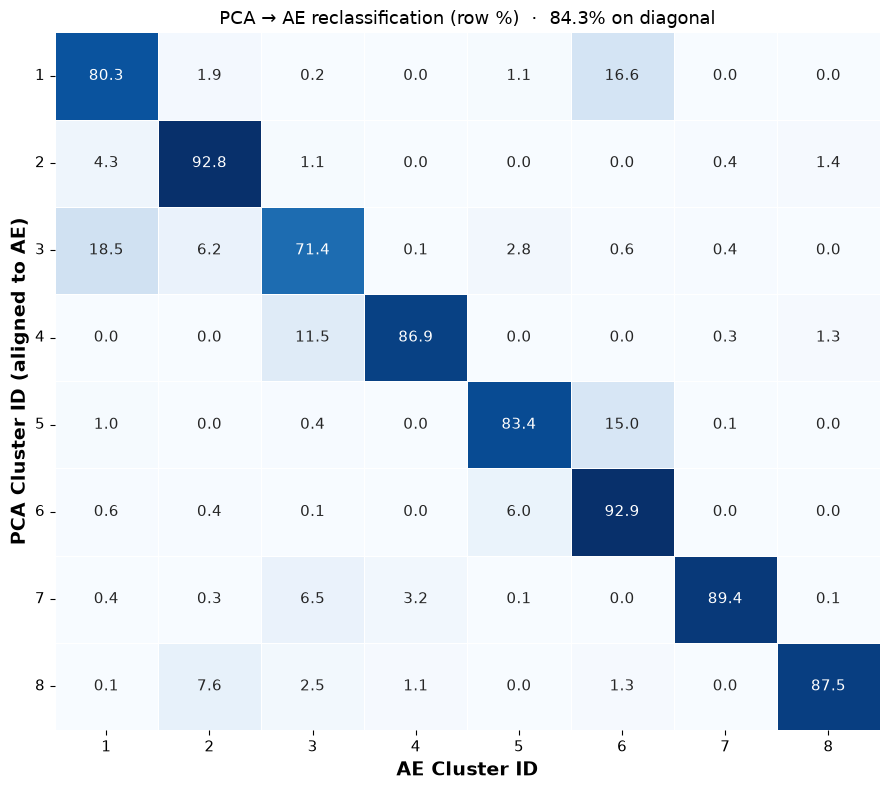

Saved transition heatmap to ./plots/pub_plots//pca_ae_transition_100d.png


In [12]:
# Transition matrix: rows = PCA cluster (aligned to AE), cols = AE cluster.
# Row-normalised: "of the OAs PCA assigns to cluster i, what % does the AE place in each
# cluster?" i.e. starting from the conventional PCA classification, where does the AE move
# areas. The diagonal is agreement; off-diagonal cells are reclassifications. This is the
# data behind the Sankey below.
trans = pd.crosstab(clusters_df['pca_cluster_aligned'], clusters_df['ae_cluster'])
trans = trans.reindex(index=range(1, n_clusters + 1),
                      columns=range(1, n_clusters + 1), fill_value=0)
trans_pct = trans.divide(trans.sum(axis=1).replace(0, np.nan), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(trans_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax, cbar=False,
            linewidths=0.5, linecolor='white', annot_kws={'size': 11})
ax.set_xlabel('AE Cluster ID', fontsize=14, fontweight='bold')
ax.set_ylabel('PCA Cluster ID (aligned to AE)', fontsize=14, fontweight='bold')
ax.set_title(f'PCA → AE reclassification (row %)  ·  {pct_agree:.1f}% on diagonal',
             fontsize=13)
ax.tick_params(axis='both', labelsize=11)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/pca_ae_transition_{target_dim}d.png", dpi=600,
            bbox_inches='tight', facecolor='white')
plt.savefig(f"{output_dir}/pca_ae_transition_{target_dim}d.pdf",
            bbox_inches='tight', transparent=True)
plt.show()
print(f"Saved transition heatmap to {output_dir}/pca_ae_transition_{target_dim}d.png")

In [13]:
# Sankey diagram: PCA clusters (left) -> AE clusters (right).
# Flow width = number of OAs; diagonal flows (i -> i) are the OAs both methods agree on.
# `trans` has rows = PCA cluster, cols = AE cluster (see cell above).
import plotly.graph_objects as go

pal = palettes_to_plot['Set1_perm03']  # cluster_id -> hex

node_labels = [f"PCA {i}" for i in range(1, n_clusters + 1)] + \
              [f"AE {i}" for i in range(1, n_clusters + 1)]
node_colors = [pal[i] for i in range(1, n_clusters + 1)] * 2

def _hex_to_rgba(h, a):
    h = h.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{a})"

sources, targets, values, link_colors = [], [], [], []
for i in range(1, n_clusters + 1):          # PCA cluster (source, left)
    for j in range(1, n_clusters + 1):      # AE cluster (target, right)
        v = int(trans.loc[i, j])
        if v == 0:
            continue
        sources.append(i - 1)
        targets.append(n_clusters + (j - 1))
        values.append(v)
        # colour by source (PCA) cluster; agreements (i==j) more opaque than reclassifications
        link_colors.append(_hex_to_rgba(pal[i], 0.65 if i == j else 0.28))

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(label=node_labels, color=node_colors, pad=15, thickness=18,
              line=dict(color='black', width=0.5)),
    link=dict(source=sources, target=targets, value=values, color=link_colors),
))
fig.update_layout(
    title_text=(f"PCA &#8594; AE cluster flows ({target_dim}D, k={n_clusters}) "
                f"&#8212; {pct_agree:.1f}% unchanged"),
    font=dict(size=13), width=900, height=700,
)

sankey_png = f"{output_dir}/pca_ae_sankey_{target_dim}d.png"
fig.write_html(f"{output_dir}/pca_ae_sankey_{target_dim}d.html")
try:
    fig.write_image(sankey_png, scale=2)  # static PNG needs kaleido + Chrome
    print(f"Saved Sankey to {sankey_png} and .html")
except Exception as e:
    print(f"Saved Sankey .html; static PNG export skipped ({type(e).__name__}: {e}).")
    print("  Run `plotly_get_chrome` in the venv to enable PNG export.")
fig.show()

Saved Sankey to ./plots/pub_plots//pca_ae_sankey_100d.png and .html


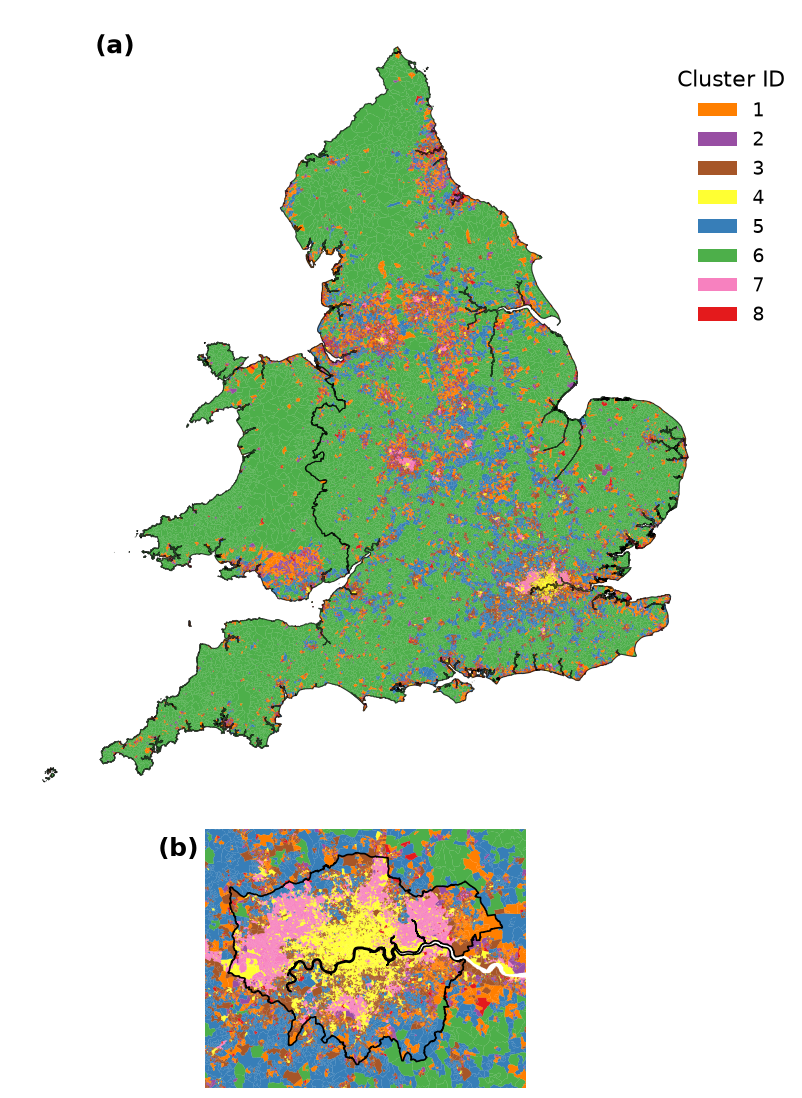

Saved: ./plots/pub_plots//publication_map_pca_100d.png


In [14]:
# Publication PCA cluster map — mirrors the AE Figure 6 layout/style so the two
# are directly comparable. Uses the published Figure 6 palette and the AE-aligned PCA
# labels, so identical colours = "the same geodemographic group".
cluster_colors = palettes_to_plot['Set1_perm03']
color_list = [cluster_colors[i] for i in range(1, n_clusters + 1)]
cmap = ListedColormap(color_list)
bounds = np.arange(0.5, n_clusters + 1.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(2, 1, figsize=(10, 14),
                         gridspec_kw={'height_ratios': [2.5, 0.8], 'hspace': 0.02})
ax_uk, ax_ldn = axes

gdf.plot(column='pca_cluster_aligned', ax=ax_uk, cmap=cmap, norm=norm,
         linewidth=0.1, edgecolor='face', legend=False)
eng_wales_gdf.boundary.plot(ax=ax_uk, linewidth=0.8, edgecolor='black', alpha=0.7)
ax_uk.text(0.12, 0.97, '(a)', transform=ax_uk.transAxes, fontsize=18,
           fontweight='bold', va='top', ha='left')
ax_uk.axis('off')

gdf_london.plot(column='pca_cluster_aligned', ax=ax_ldn, cmap=cmap, norm=norm,
                linewidth=0.1, edgecolor='face', legend=False)
london_boundary.boundary.plot(ax=ax_ldn, linewidth=1.2, edgecolor='black')
ax_ldn.set_xlim(london_bounds['minx'], london_bounds['maxx'])
ax_ldn.set_ylim(london_bounds['miny'], london_bounds['maxy'])
ax_ldn.set_aspect('equal')
ax_ldn.text(-0.02, 0.97, '(b)', transform=ax_ldn.transAxes, fontsize=18,
            fontweight='bold', va='top', ha='right')
ax_ldn.axis('off')

for ax in [ax_uk, ax_ldn]:
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(1.5); spine.set_edgecolor('black')

legend_elements = [Patch(facecolor=cluster_colors[i], label=str(i))
                   for i in range(1, n_clusters + 1)]
fig.legend(handles=legend_elements, loc='upper right', ncol=1, fontsize=14,
           frameon=False, title='Cluster ID', title_fontsize=16,
           bbox_to_anchor=(0.95, 0.85))

plt.tight_layout()
save_path = f"{output_dir}/publication_map_pca_{target_dim}d.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(save_path.replace('.png', '_transparent.png'), dpi=600,
            bbox_inches='tight', facecolor='none', edgecolor='none')
plt.show()
print(f"Saved: {save_path}")

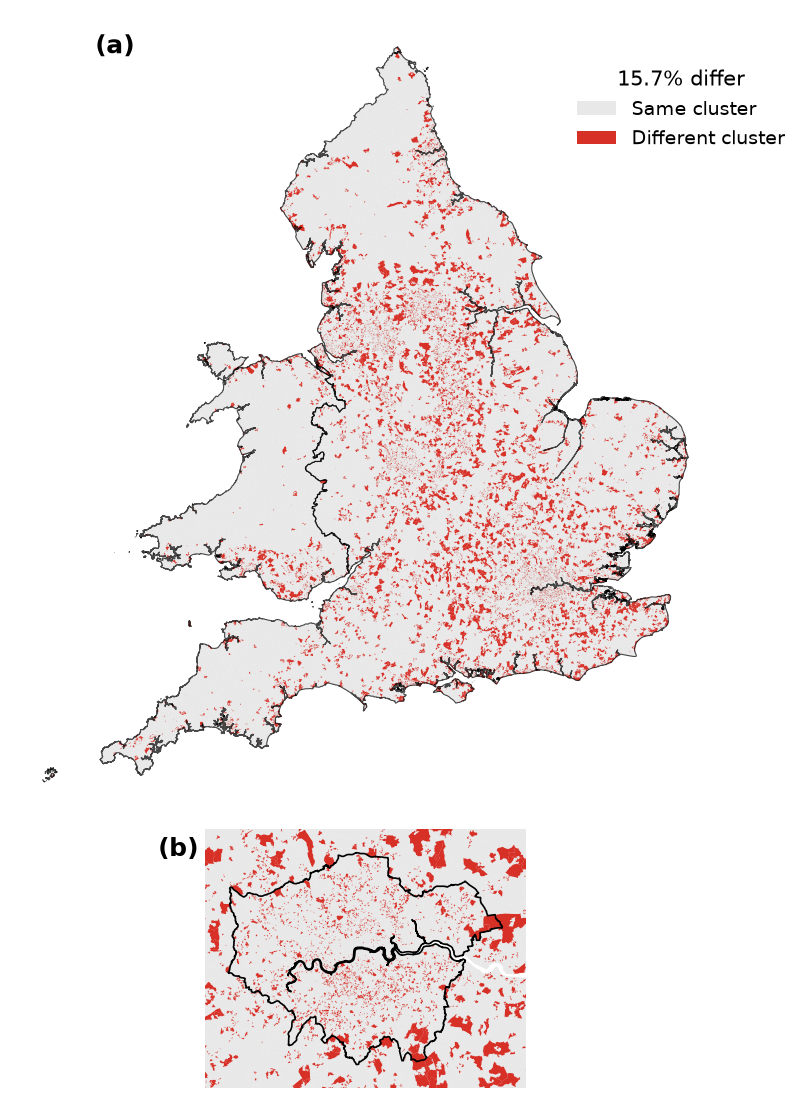

Saved: ./plots/pub_plots//ae_pca_disagreement_map_100d.png

Largest PCA -> AE reclassification flows (off-diagonal):
  PCA 1 -> AE 6: 7,398 OAs (16.6% of PCA cluster 1)
  PCA 3 -> AE 1: 4,844 OAs (18.5% of PCA cluster 3)
  PCA 5 -> AE 6: 4,139 OAs (15.0% of PCA cluster 5)
  PCA 4 -> AE 3: 2,033 OAs (11.5% of PCA cluster 4)
  PCA 3 -> AE 2: 1,622 OAs (6.2% of PCA cluster 3)
  PCA 2 -> AE 1: 1,331 OAs (4.3% of PCA cluster 2)
  PCA 8 -> AE 2: 1,181 OAs (7.6% of PCA cluster 8)
  PCA 7 -> AE 3: 925 OAs (6.5% of PCA cluster 7)
  PCA 1 -> AE 2: 865 OAs (1.9% of PCA cluster 1)
  PCA 3 -> AE 5: 731 OAs (2.8% of PCA cluster 3)


In [15]:
# Disagreement map: where do PCA and AE place an OA in DIFFERENT clusters?
# (uses the AE-aligned PCA labels, so a difference is a genuine reclassification)
disagree_color = '#d73027'   # red
agree_color    = '#e8e8e8'   # light grey
dis_cmap = ListedColormap([agree_color, disagree_color])
dis_norm = BoundaryNorm([-0.5, 0.5, 1.5], dis_cmap.N)

gdf['disagree'] = 1 - gdf['agreement']
gdf_london = gdf.cx[london_bounds['minx']:london_bounds['maxx'],
                    london_bounds['miny']:london_bounds['maxy']]

fig, axes = plt.subplots(2, 1, figsize=(10, 14),
                         gridspec_kw={'height_ratios': [2.5, 0.8], 'hspace': 0.02})
ax_uk, ax_ldn = axes

gdf.plot(column='disagree', ax=ax_uk, cmap=dis_cmap, norm=dis_norm,
         linewidth=0.1, edgecolor='face', legend=False)
eng_wales_gdf.boundary.plot(ax=ax_uk, linewidth=0.8, edgecolor='black', alpha=0.7)
ax_uk.text(0.12, 0.97, '(a)', transform=ax_uk.transAxes, fontsize=18,
           fontweight='bold', va='top', ha='left')
ax_uk.axis('off')

gdf_london.plot(column='disagree', ax=ax_ldn, cmap=dis_cmap, norm=dis_norm,
                linewidth=0.1, edgecolor='face', legend=False)
london_boundary.boundary.plot(ax=ax_ldn, linewidth=1.2, edgecolor='black')
ax_ldn.set_xlim(london_bounds['minx'], london_bounds['maxx'])
ax_ldn.set_ylim(london_bounds['miny'], london_bounds['maxy'])
ax_ldn.set_aspect('equal')
ax_ldn.text(-0.02, 0.97, '(b)', transform=ax_ldn.transAxes, fontsize=18,
            fontweight='bold', va='top', ha='right')
ax_ldn.axis('off')

for ax in [ax_uk, ax_ldn]:
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(1.5); spine.set_edgecolor('black')

legend_elements = [Patch(facecolor=agree_color, label='Same cluster'),
                   Patch(facecolor=disagree_color, label='Different cluster')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=14, frameon=False,
           title=f'{100 - pct_agree:.1f}% differ', title_fontsize=15,
           bbox_to_anchor=(0.95, 0.85))

plt.tight_layout()
save_path = f"{output_dir}/ae_pca_disagreement_map_{target_dim}d.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(save_path.replace('.png', '_transparent.png'), dpi=600,
            bbox_inches='tight', facecolor='none', edgecolor='none')
plt.show()
print(f"Saved: {save_path}")

# Largest reclassification flows (off-diagonal) to anchor the policy discussion.
# `trans` rows = PCA cluster, cols = AE cluster: PCA i -> AE j.
print("\nLargest PCA -> AE reclassification flows (off-diagonal):")
off = [(i, j, int(trans.loc[i, j]), trans_pct.loc[i, j])
       for i in range(1, n_clusters + 1) for j in range(1, n_clusters + 1)
       if i != j and trans.loc[i, j] > 0]
for i, j, cnt, pctv in sorted(off, key=lambda x: -x[2])[:10]:
    print(f"  PCA {i} -> AE {j}: {cnt:,} OAs ({pctv:.1f}% of PCA cluster {i})")

### Side-by-side comparison, cross-tabulation and the geography of disagreement

Companion figures to the maps above, all built on the **AE-aligned PCA labels** so a colour
change between methods is a genuine reclassification rather than a KMeans label permutation:

1. **Side-by-side AE / PCA cluster maps** (national + London) on one shared palette.
2. **AE x PCA cross-tabulation** (row % of each AE cluster), styled like the OAC overlap heatmap.
3. **Combined AE / PCA overlap with OAC** — each cell split on the diagonal, AE in the upper-left
   triangle, PCA in the lower-right, so two-tone cells are where the methods differ.
4. **Disagreement aggregated to LAD and MSOA** — the scales policy is actually delivered at.
5. **Moved-OA maps** — binary (moved / not moved) and coloured by the dominant AE -> PCA flows.

Note the cross-tab, the flow maps and the Sankey read in opposite directions: the transition
matrix above is PCA -> AE (where does the AE move areas relative to the conventional baseline),
whereas the cross-tab and flow maps below are AE -> PCA (rows are AE clusters).

In [ ]:
# === AE and PCA cluster maps side by side ===
# Same palette and the AE-aligned PCA labels, so identical colours mean "the same
# geodemographic group": any colour change between the left and right column is a
# reclassification. Top row = England & Wales, bottom row = London.
cluster_colors = palettes_to_plot['Set1_perm03']
cmap = ListedColormap([cluster_colors[i] for i in range(1, n_clusters + 1)])
norm = BoundaryNorm(np.arange(0.5, n_clusters + 1.5, 1), cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(15, 14),
                         gridspec_kw={'height_ratios': [2.5, 1.0],
                                      'hspace': 0.02, 'wspace': 0.02})

panels = [
    ('ae_cluster',          axes[0, 0], '(a)', False),
    ('pca_cluster_aligned', axes[0, 1], '(b)', False),
    ('ae_cluster',          axes[1, 0], '(c)', True),
    ('pca_cluster_aligned', axes[1, 1], '(d)', True),
]

for col, ax, label, is_london in panels:
    g = gdf_london if is_london else gdf
    g.plot(column=col, ax=ax, cmap=cmap, norm=norm,
           linewidth=0.1, edgecolor='face', legend=False)
    if is_london:
        london_boundary.boundary.plot(ax=ax, linewidth=1.2, edgecolor='black')
        ax.set_xlim(london_bounds['minx'], london_bounds['maxx'])
        ax.set_ylim(london_bounds['miny'], london_bounds['maxy'])
        ax.set_aspect('equal')
        ax.text(-0.02, 0.97, label, transform=ax.transAxes,
                fontsize=18, fontweight='bold', va='top', ha='right')
    else:
        eng_wales_gdf.boundary.plot(ax=ax, linewidth=0.8, edgecolor='black', alpha=0.7)
        ax.text(0.12, 0.97, label, transform=ax.transAxes,
                fontsize=18, fontweight='bold', va='top', ha='left')
    ax.axis('off')

axes[0, 0].set_title('Autoencoder', fontsize=20, fontweight='bold', pad=10)
axes[0, 1].set_title('PCA', fontsize=20, fontweight='bold', pad=10)

legend_elements = [Patch(facecolor=cluster_colors[i], label=str(i))
                   for i in range(1, n_clusters + 1)]
fig.legend(handles=legend_elements, loc='lower center', ncol=n_clusters, fontsize=14,
           frameon=False, title='Cluster ID', title_fontsize=15,
           bbox_to_anchor=(0.5, 0.02))
fig.subplots_adjust(bottom=0.08)

save_path = f"{output_dir}/ae_pca_maps_side_by_side_{target_dim}d.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(save_path.replace('.png', '_transparent.png'), dpi=600,
            bbox_inches='tight', facecolor='none', edgecolor='none')
plt.show()
print(f"Saved: {save_path}")

Creating AE cluster vs PCA cluster cross-tabulation...



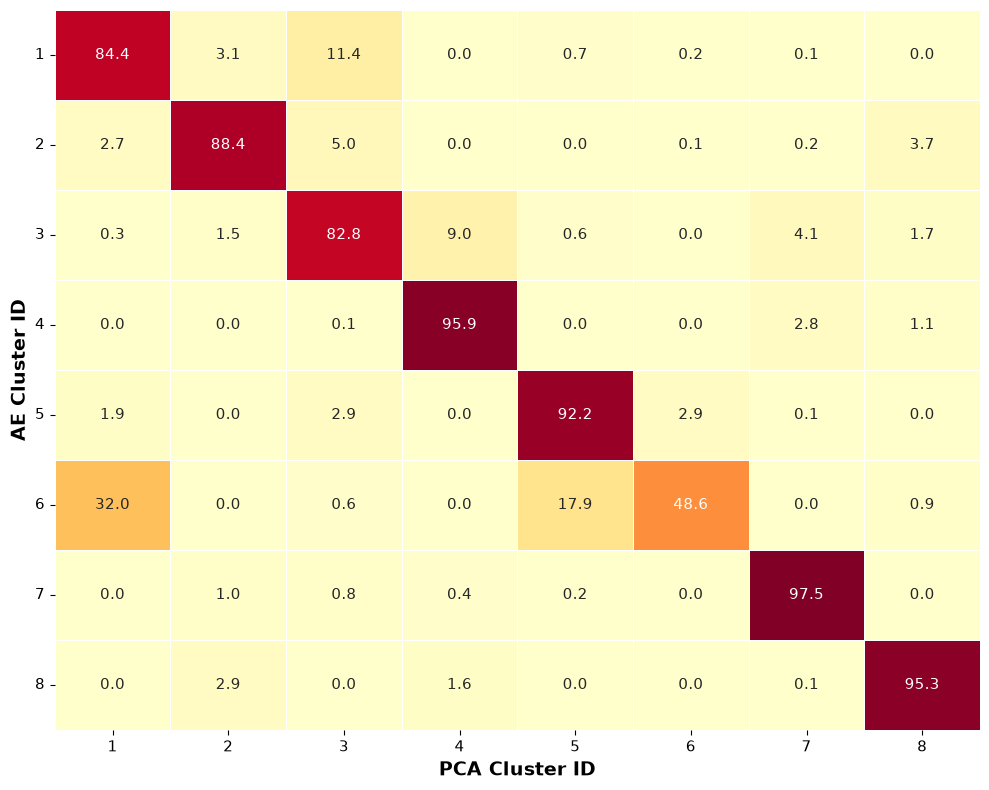

Saved heatmap to ./plots/pub_plots//ae_pca_crosstab_100d.png

Largest AE -> PCA reassignments:
 ae  pca  n_oas  pct_of_ae_cluster
  6    1   7398               32.0
  1    3   4844               11.4
  6    5   4139               17.9
  3    4   2033                9.0
  2    3   1622                5.0
  1    2   1331                3.1
  2    8   1181                3.7
  3    7    925                4.1


In [17]:
# === AE x PCA cross-tabulation (styled as the OAC overlap figure above) ===
# Uses the AE-aligned PCA labels, so the diagonal is agreement between the two methods.
print("Creating AE cluster vs PCA cluster cross-tabulation...\n")

cluster_ids = list(range(1, n_clusters + 1))
ae_pca_counts = pd.crosstab(clusters_df['ae_cluster'], clusters_df['pca_cluster_aligned'])
ae_pca_counts = ae_pca_counts.reindex(index=cluster_ids, columns=cluster_ids, fill_value=0)
ae_pca_counts.index.name, ae_pca_counts.columns.name = 'ae_cluster', 'pca_cluster'

# Row-wise percentages: for each AE cluster, what % of its OAs fall into each PCA cluster
ae_pca_percent = ae_pca_counts.divide(
    ae_pca_counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
ae_pca_percent = ae_pca_percent.fillna(0)
ae_pca_percent.index = [str(i) for i in ae_pca_percent.index]
ae_pca_percent.columns = [str(i) for i in ae_pca_percent.columns]

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(ae_pca_percent, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, cbar=False,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11})

ax.set_xlabel('PCA Cluster ID', fontsize=14, fontweight='bold')
ax.set_ylabel('AE Cluster ID', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f"{output_dir}/ae_pca_crosstab_{target_dim}d.png",
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(f"{output_dir}/ae_pca_crosstab_{target_dim}d.jpeg",
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(f"{output_dir}/ae_pca_crosstab_{target_dim}d_transparent.png",
            dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(f"{output_dir}/ae_pca_crosstab_{target_dim}d_transparent.pdf",
            bbox_inches='tight', transparent=True)
plt.show()

ae_pca_percent.to_csv(f"{input_dir}/ae_pca_crosstab_percent_{target_dim}d.csv")
ae_pca_counts.to_csv(f"{input_dir}/ae_pca_crosstab_counts_{target_dim}d.csv")
print(f"Saved heatmap to {output_dir}/ae_pca_crosstab_{target_dim}d.png")

# Largest off-diagonal flows, for the discussion in the text
flows = (ae_pca_counts.stack().rename('n_oas').reset_index()
         .rename(columns={'ae_cluster': 'ae', 'pca_cluster': 'pca'}))
flows = flows[flows['ae'] != flows['pca']].sort_values('n_oas', ascending=False)
flows['pct_of_ae_cluster'] = flows.apply(
    lambda r: r['n_oas'] / ae_pca_counts.loc[r['ae']].sum() * 100, axis=1)
print("\nLargest AE -> PCA reassignments:")
print(flows.head(8).round(1).to_string(index=False))

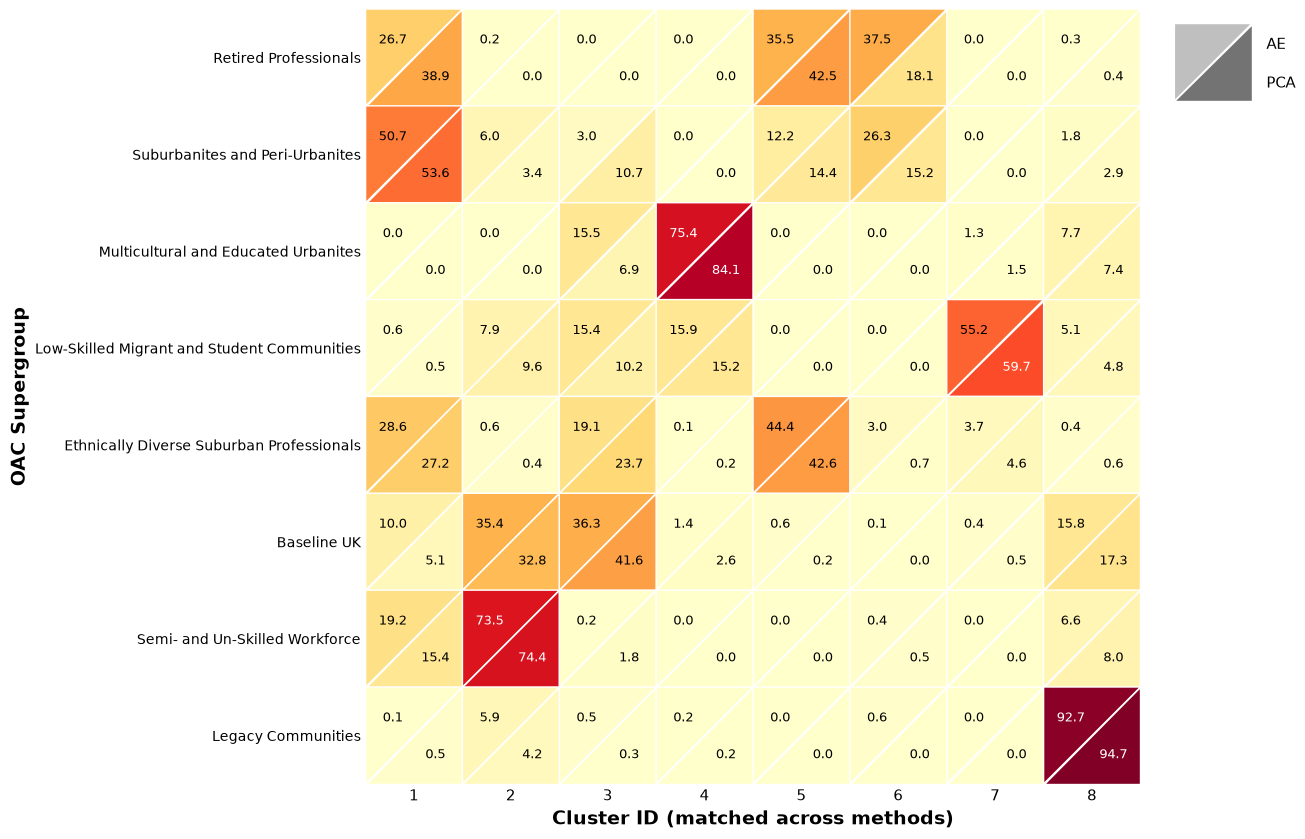


Largest AE - PCA gaps (percentage points of an OAC supergroup):
OAC_supergroup                        cluster
Retired Professionals                 6          19.4
                                      1         -12.2
Suburbanites and Peri-Urbanites       6          11.1
Multicultural and Educated Urbanites  4          -8.7
                                      3           8.6
Suburbanites and Peri-Urbanites       3          -7.7
Retired Professionals                 5          -7.1
Baseline UK                           3          -5.3

Saved: ./plots/pub_plots//ae_pca_oac_overlap_combined_100d.png


In [ ]:
# === Combined AE / PCA overlap with OAC: both values in every cell ===
# Each square is split along its diagonal: upper-left triangle = AE, lower-right = PCA.
# Both triangles are shaded on the same colour scale, so a two-tone square is a
# cell where the two methods place different shares of an OAC supergroup.
from matplotlib.patches import Polygon

# PCA counterpart of `ae_percent_named` (rows = OAC supergroup, cols = cluster ID,
# row-normalised), on the AE-aligned PCA labels so the columns are comparable.
pca_counts_named, pca_percent_named = cluster_oac_overlap_named(
    clusters_df['pca_cluster_aligned'].values, oac['Supergroup8'].values, oac_names
)

vmax = max(ae_percent_named.values.max(), pca_percent_named.values.max())
cmap = plt.get_cmap('YlOrRd')
n_rows, n_cols = ae_percent_named.shape

fig, ax = plt.subplots(figsize=(12, 8.5))

for i in range(n_rows):
    for j in range(n_cols):
        ae_val = ae_percent_named.iloc[i, j]
        pca_val = pca_percent_named.iloc[i, j]
        ax.add_patch(Polygon([[j, i], [j + 1, i], [j, i + 1]],
                             facecolor=cmap(ae_val / vmax), edgecolor='white', lw=1.0))
        ax.add_patch(Polygon([[j + 1, i], [j + 1, i + 1], [j, i + 1]],
                             facecolor=cmap(pca_val / vmax), edgecolor='white', lw=1.0))
        ax.text(j + 0.28, i + 0.32, f"{ae_val:.1f}", ha='center', va='center',
                fontsize=9.5, color='white' if ae_val / vmax > 0.6 else 'black')
        ax.text(j + 0.72, i + 0.70, f"{pca_val:.1f}", ha='center', va='center',
                fontsize=9.5, color='white' if pca_val / vmax > 0.6 else 'black')

ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)
ax.set_aspect('equal')
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(ae_percent_named.columns, fontsize=11)
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(ae_percent_named.index, fontsize=10)
ax.set_xlabel('Cluster ID', fontsize=14, fontweight='bold')
ax.set_ylabel('OAC Supergroup', fontsize=14, fontweight='bold')
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Key
key_x, key_y, key_s = n_cols + 0.35, 0.15, 0.8
ax.add_patch(Polygon([[key_x, key_y], [key_x + key_s, key_y], [key_x, key_y + key_s]],
                     facecolor='0.75', edgecolor='white', clip_on=False))
ax.add_patch(Polygon([[key_x + key_s, key_y], [key_x + key_s, key_y + key_s], [key_x, key_y + key_s]],
                     facecolor='0.45', edgecolor='white', clip_on=False))
ax.text(key_x + key_s + 0.15, key_y + 0.22, 'AE', fontsize=11, va='center', clip_on=False)
ax.text(key_x + key_s + 0.15, key_y + 0.62, 'PCA', fontsize=11, va='center', clip_on=False)

plt.tight_layout()
save_path = f"{output_dir}/ae_pca_oac_overlap_combined_{target_dim}d"
plt.savefig(f"{save_path}.png", dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(f"{save_path}.jpeg", dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(f"{save_path}_transparent.png", dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(f"{save_path}_transparent.pdf", bbox_inches='tight', transparent=True)
plt.show()

# Largest AE - PCA differences in how each OAC supergroup is distributed
diff = (ae_percent_named - pca_percent_named).round(1)
diff.to_csv(f"{input_dir}/ae_minus_pca_oac_overlap_{target_dim}d.csv")
stacked = diff.stack()
stacked.index.names = ['OAC_supergroup', 'cluster']
print("\nLargest AE - PCA gaps (percentage points of an OAC supergroup):")
print(stacked.reindex(stacked.abs().sort_values(ascending=False).index).head(8).to_string())
print(f"\nSaved: {save_path}.png")

In [19]:
# === Aggregate AE/PCA disagreement to LAD and MSOA ===
# OA-level disagreement is noisy and OAs are too small to key policy to; LAD and MSOA are
# the scales at which resources are actually allocated. For each area: what % of its
# constituent OAs are placed in different clusters by the two methods?
lookup_path = ("../data/geofiles/Output_Area_to_Lower_layer_Super_Output_Area_to_"
               "Middle_layer_Super_Output_Area_to_Local_Authority_District_"
               "(December_2021)_Lookup_in_England_and_Wales_v3.csv")
lookup = pd.read_csv(lookup_path, encoding='utf-8-sig')[['OA21CD', 'MSOA21CD', 'LAD22CD']]

dis = clusters_df[['ae_cluster', 'pca_cluster_aligned']].copy()
dis['disagree'] = (dis['ae_cluster'] != dis['pca_cluster_aligned']).astype(int)
dis = dis.merge(lookup, left_index=True, right_on='OA21CD', how='left')
print(f"OAs without a lookup match: {dis['LAD22CD'].isna().sum()}")


def aggregate_disagreement(key):
    """% of an area's OAs classified differently by AE and PCA."""
    a = dis.groupby(key)['disagree'].agg(n_oas='size', n_diff='sum')
    a['disagree_pct'] = a['n_diff'] / a['n_oas'] * 100
    return a.reset_index()


lad_dis = aggregate_disagreement('LAD22CD')
msoa_dis = aggregate_disagreement('MSOA21CD')

# Attach boundaries (lads_gdf is already loaded above; MSOA boundaries come from the
# same shapefile used in notebook 6)
lad_disagreement_gdf = lads_gdf[['LAD22CD', 'LAD22NM', 'geometry']].merge(
    lad_dis, on='LAD22CD', how='right')
msoa_gdf = gpd.read_file(
    "../data/geofiles/Middle_layer_Super_Output_Areas_(December_2021)_Boundaries_EW_BFE_(V8)_and_RUC"
)[['MSOA21CD', 'geometry']]
msoa_disagreement_gdf = msoa_gdf.merge(msoa_dis, on='MSOA21CD', how='right')

for name, g in [('LAD', lad_disagreement_gdf), ('MSOA', msoa_disagreement_gdf)]:
    if g.crs != gdf.crs:
        g = g.to_crs(gdf.crs)
    if name == 'LAD':
        lad_disagreement_gdf = g
    else:
        msoa_disagreement_gdf = g
    print(f"{name}: {len(g)} areas, disagreement {g['disagree_pct'].min():.1f}%"
          f" - {g['disagree_pct'].max():.1f}% (median {g['disagree_pct'].median():.1f}%)")

print("\nLADs where AE and PCA disagree most:")
print(lad_disagreement_gdf.nlargest(10, 'disagree_pct')[
    ['LAD22NM', 'n_oas', 'n_diff', 'disagree_pct']].round(1).to_string(index=False))

lad_disagreement_gdf.drop(columns='geometry').to_csv(
    f"{input_dir}/ae_pca_disagreement_by_lad_{target_dim}d.csv", index=False)
msoa_disagreement_gdf.drop(columns='geometry').to_csv(
    f"{input_dir}/ae_pca_disagreement_by_msoa_{target_dim}d.csv", index=False)

OAs without a lookup match: 0
LAD: 331 areas, disagreement 2.9% - 41.4% (median 15.7%)
MSOA: 7264 areas, disagreement 0.0% - 96.2% (median 13.6%)

LADs where AE and PCA disagree most:
        LAD22NM  n_oas  n_diff  disagree_pct
       Tendring    507     210          41.4
  Isle of Wight    476     190          39.9
         Rother    317     125          39.4
           Arun    548     205          37.4
     New Forest    592     218          36.8
     East Devon    487     178          36.6
         Dorset   1284     433          33.7
    Teignbridge    441     148          33.6
Isles of Scilly      9       3          33.3
         Torbay    479     158          33.0


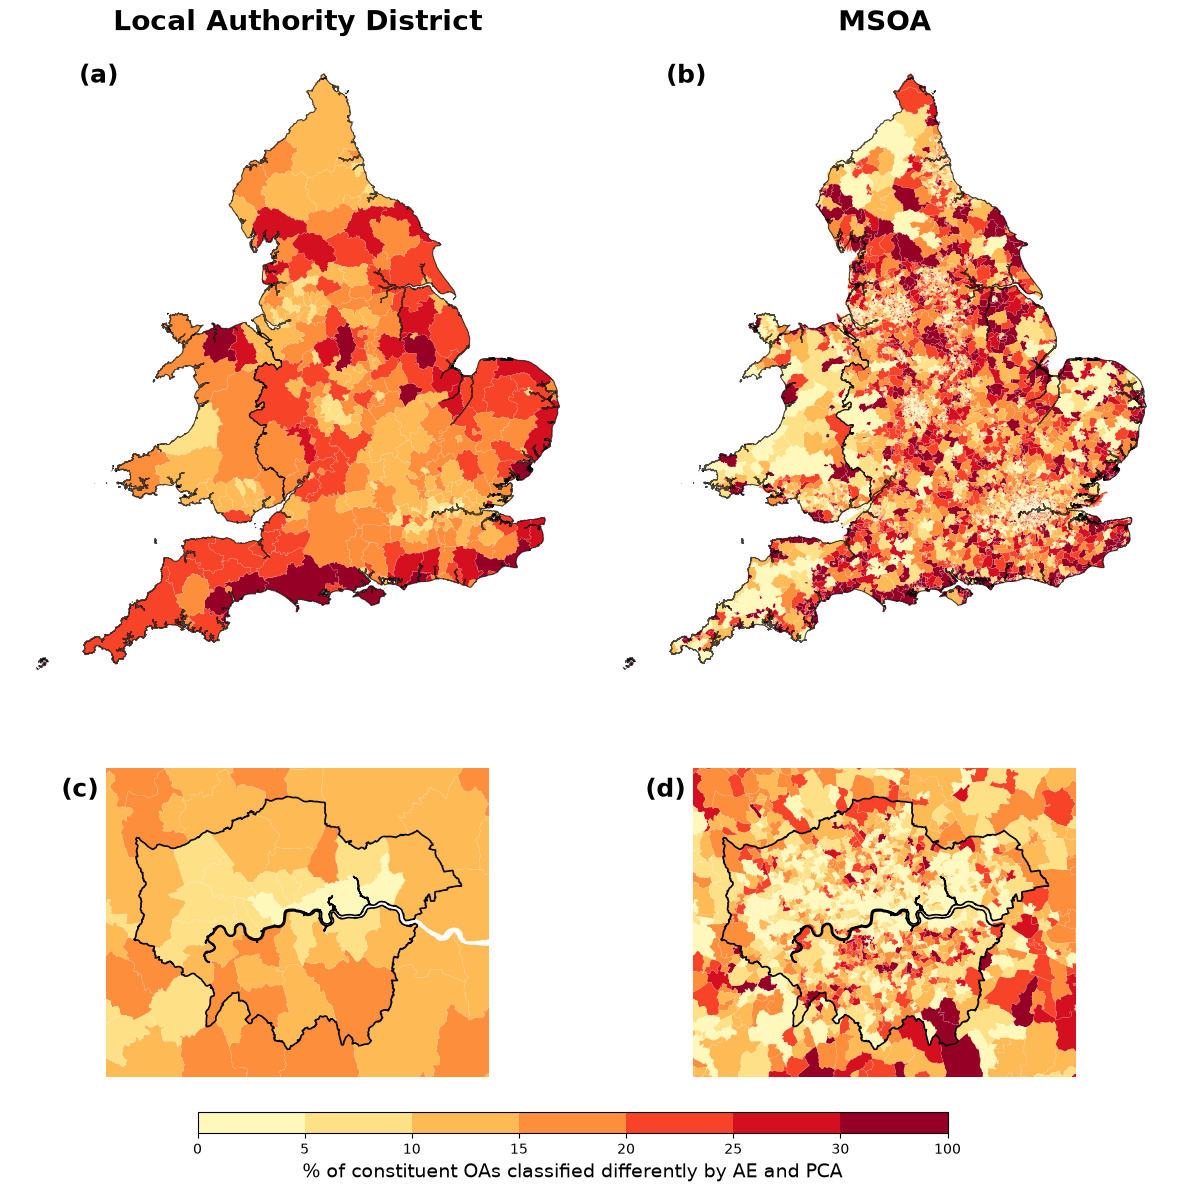

Saved: ./plots/pub_plots//ae_pca_disagreement_maps_100d.png


In [20]:
# === Disagreement maps: LAD and MSOA, shared colour scale ===
from matplotlib.cm import ScalarMappable

breaks = [0, 5, 10, 15, 20, 25, 30, 100]
dis_cmap = ListedColormap(plt.get_cmap('YlOrRd')(np.linspace(0.05, 0.95, len(breaks) - 1)))
dis_norm = BoundaryNorm(breaks, dis_cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(15, 14),
                         gridspec_kw={'height_ratios': [2.5, 1.0],
                                      'hspace': 0.02, 'wspace': 0.02})

panels = [
    (lad_disagreement_gdf,  axes[0, 0], '(a)', False),
    (msoa_disagreement_gdf, axes[0, 1], '(b)', False),
    (lad_disagreement_gdf,  axes[1, 0], '(c)', True),
    (msoa_disagreement_gdf, axes[1, 1], '(d)', True),
]

for g, ax, label, is_london in panels:
    if is_london:
        g = g.cx[london_bounds['minx']:london_bounds['maxx'],
                 london_bounds['miny']:london_bounds['maxy']]
    g.plot(column='disagree_pct', ax=ax, cmap=dis_cmap, norm=dis_norm,
           linewidth=0.05, edgecolor='white')
    if is_london:
        london_boundary.boundary.plot(ax=ax, linewidth=1.2, edgecolor='black')
        ax.set_xlim(london_bounds['minx'], london_bounds['maxx'])
        ax.set_ylim(london_bounds['miny'], london_bounds['maxy'])
        ax.set_aspect('equal')
        ax.text(-0.02, 0.97, label, transform=ax.transAxes,
                fontsize=18, fontweight='bold', va='top', ha='right')
    else:
        eng_wales_gdf.boundary.plot(ax=ax, linewidth=0.8, edgecolor='black', alpha=0.7)
        ax.text(0.12, 0.97, label, transform=ax.transAxes,
                fontsize=18, fontweight='bold', va='top', ha='left')
    ax.axis('off')

axes[0, 0].set_title('Local Authority District', fontsize=20, fontweight='bold', pad=10)
axes[0, 1].set_title('MSOA', fontsize=20, fontweight='bold', pad=10)

sm = ScalarMappable(cmap=dis_cmap, norm=dis_norm)
sm.set_array([])
cax = fig.add_axes([0.25, 0.06, 0.5, 0.015])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', ticks=breaks, spacing='uniform')
cbar.ax.set_xticklabels([str(b) for b in breaks])
cbar.set_label('% of constituent OAs classified differently by AE and PCA', fontsize=14)
fig.subplots_adjust(bottom=0.10)

save_path = f"{output_dir}/ae_pca_disagreement_maps_{target_dim}d.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(save_path.replace('.png', '_transparent.png'), dpi=600,
            bbox_inches='tight', facecolor='none', edgecolor='none')
plt.show()
print(f"Saved: {save_path}")

In [21]:
# === Which OAs move, and where do they move to? ===
# `flow` labels each reclassified OA with its AE cluster -> PCA cluster pair; the maps
# below show the handful of flows that account for most of the movement.
COL_BASE  = '#ececec'   # both methods agree
COL_MOVED = '#d73027'   # classified differently (binary map)
COL_OTHER = '#9e9e9e'   # a flow outside the top few (flow map)

gdf['agree'] = gdf['agreement'].astype(bool)
gdf['flow'] = np.where(
    gdf['agree'], None,
    gdf['ae_cluster'].astype('Int64').astype(str) + ' → '
    + gdf['pca_cluster_aligned'].astype('Int64').astype(str))
gdf_london = gdf.cx[london_bounds['minx']:london_bounds['maxx'],
                    london_bounds['miny']:london_bounds['maxy']]

flow_counts = gdf.loc[~gdf['agree'], 'flow'].value_counts()
n_top = 5
top_flows = list(flow_counts.head(n_top).index)
flow_palette = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#e6ab02']
flow_colors = {f: flow_palette[i] for i, f in enumerate(top_flows)}

n_moved = int((~gdf['agree']).sum())
print(f"OAs classified differently: {n_moved:,} ({n_moved / len(gdf) * 100:.1f}%)")
print(f"Top {n_top} flows cover {flow_counts.head(n_top).sum() / n_moved * 100:.1f}%"
      f" of all movement:")
for f in top_flows:
    print(f"  AE {f} PCA: {flow_counts[f]:,} OAs ({flow_counts[f] / n_moved * 100:.1f}% of moved)")

OAs classified differently: 29,728 (15.7%)
Top 5 flows cover 67.4% of all movement:
  AE 6 → 1 PCA: 7,398 OAs (24.9% of moved)
  AE 1 → 3 PCA: 4,844 OAs (16.3% of moved)
  AE 6 → 5 PCA: 4,139 OAs (13.9% of moved)
  AE 3 → 4 PCA: 2,033 OAs (6.8% of moved)
  AE 2 → 3 PCA: 1,622 OAs (5.5% of moved)


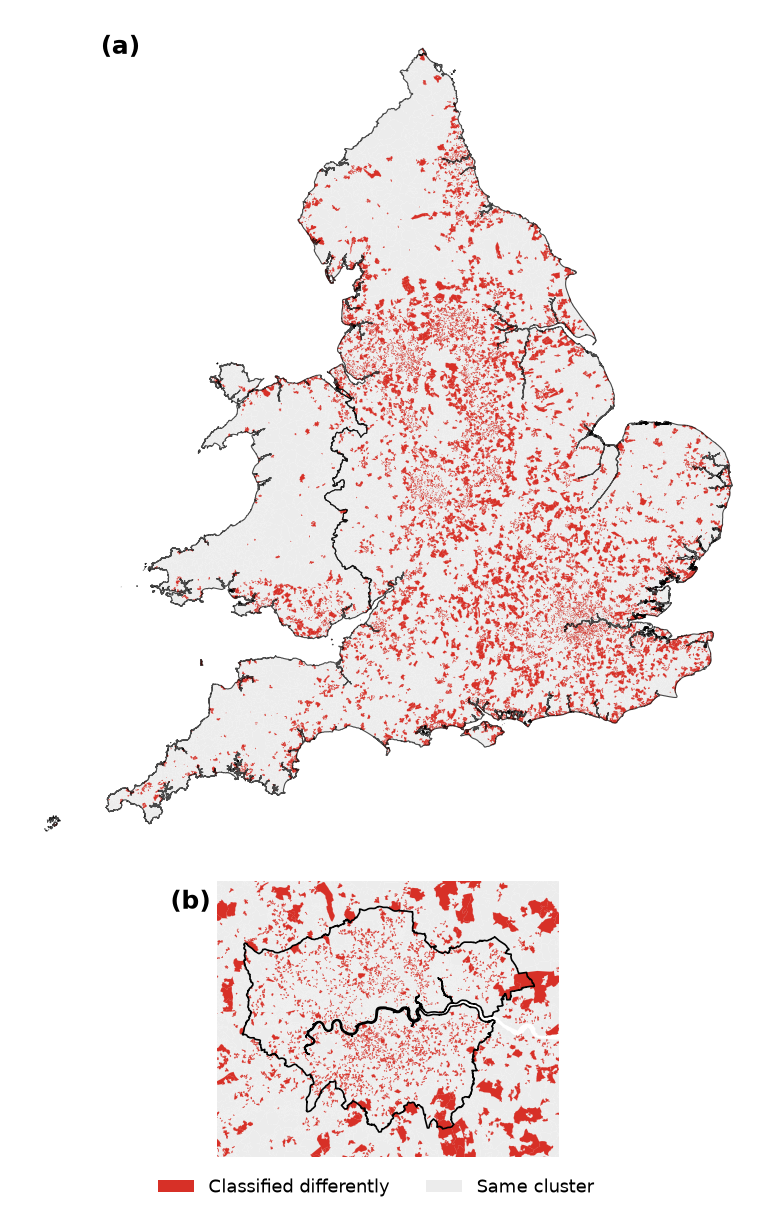

Saved: ./plots/pub_plots//ae_pca_moved_oas_binary_100d.png


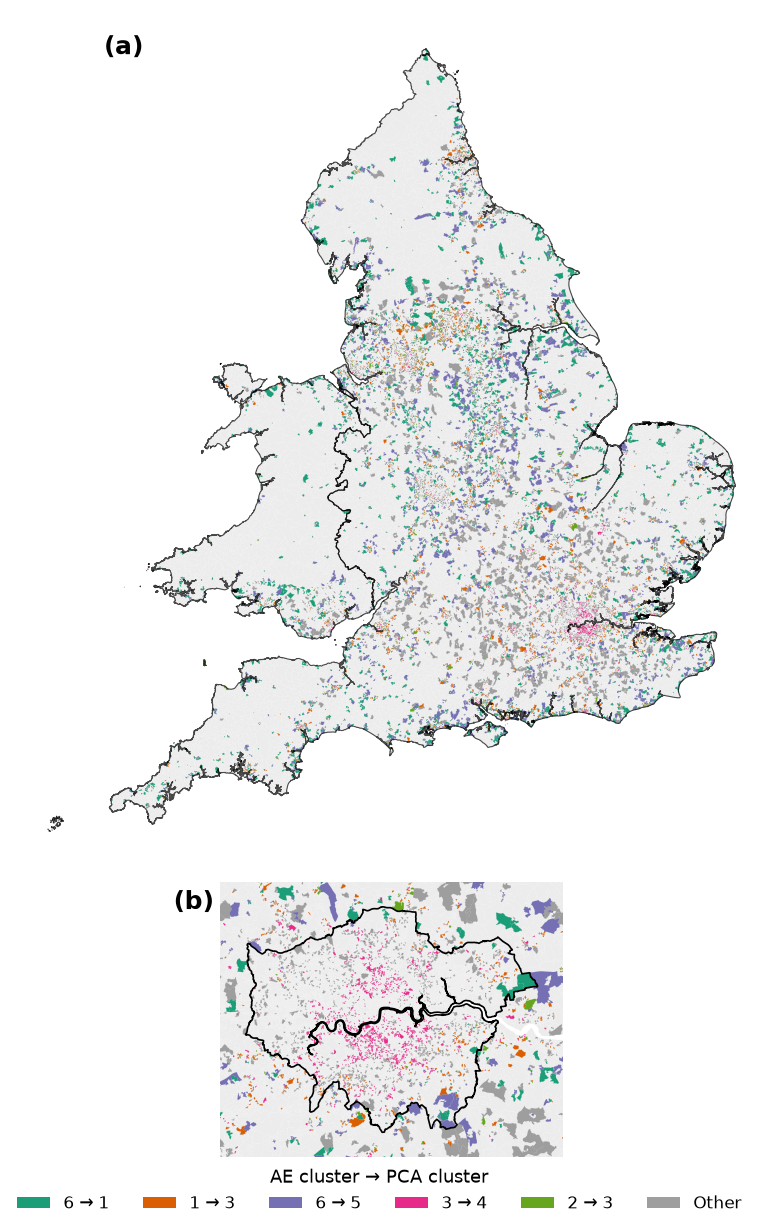

Saved: ./plots/pub_plots//ae_pca_moved_oas_flows_100d.png


In [22]:
def plot_moved(mode, fname):
    fig, axes = plt.subplots(2, 1, figsize=(10, 14),
                             gridspec_kw={'height_ratios': [2.5, 0.8], 'hspace': 0.02})
    for ax, g, is_london, label in [(axes[0], gdf, False, '(a)'),
                                    (axes[1], gdf_london, True, '(b)')]:
        g.plot(ax=ax, color=COL_BASE, linewidth=0, edgecolor='none')
        moved = g[~g['agree']]
        if mode == 'binary':
            moved.plot(ax=ax, color=COL_MOVED, linewidth=0.1, edgecolor='face')
        else:
            # 'Other' first so the named flows sit on top
            moved[~moved['flow'].isin(top_flows)].plot(
                ax=ax, color=COL_OTHER, linewidth=0.1, edgecolor='face')
            for f in top_flows:
                sub = moved[moved['flow'] == f]
                if len(sub):
                    sub.plot(ax=ax, color=flow_colors[f], linewidth=0.1, edgecolor='face')
        if is_london:
            london_boundary.boundary.plot(ax=ax, linewidth=1.2, edgecolor='black')
            ax.set_xlim(london_bounds['minx'], london_bounds['maxx'])
            ax.set_ylim(london_bounds['miny'], london_bounds['maxy'])
            ax.set_aspect('equal')
            ax.text(-0.02, 0.97, label, transform=ax.transAxes,
                    fontsize=18, fontweight='bold', va='top', ha='right')
        else:
            eng_wales_gdf.boundary.plot(ax=ax, linewidth=0.8, edgecolor='black', alpha=0.7)
            ax.text(0.12, 0.97, label, transform=ax.transAxes,
                    fontsize=18, fontweight='bold', va='top', ha='left')
        ax.axis('off')

    if mode == 'binary':
        handles = [Patch(facecolor=COL_MOVED, label='Classified differently'),
                   Patch(facecolor=COL_BASE, label='Same cluster')]
        fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=13,
                   frameon=False, bbox_to_anchor=(0.5, 0.02))
    else:
        handles = ([Patch(facecolor=flow_colors[f], label=f) for f in top_flows]
                   + [Patch(facecolor=COL_OTHER, label='Other')])
        fig.legend(handles=handles, loc='lower center', ncol=6, fontsize=12, frameon=False,
                   title='AE cluster → PCA cluster', title_fontsize=13,
                   bbox_to_anchor=(0.5, 0.01))
    fig.subplots_adjust(bottom=0.06)

    save_path = f"{output_dir}/{fname}_{target_dim}d.png"
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.savefig(save_path.replace('.png', '_transparent.png'), dpi=600,
                bbox_inches='tight', facecolor='none', edgecolor='none')
    plt.show()
    print(f"Saved: {save_path}")


plot_moved('binary', 'ae_pca_moved_oas_binary')
plot_moved('flows', 'ae_pca_moved_oas_flows')